# QM9: From MLPs to GNNs

**Goal:** Predict the HOMO-LUMO gap of small molecules, progressively using more structure.

| Model | Input | Structure used |
|-------|-------|----------------|
| **MLP** | Atom counts | None — just a bag of elements |
| **Deep Sets** | Per-atom features (element + xyz) | Atoms as a **set** (order doesn't matter) |
| **GCN** | Per-atom features + bonds | Full molecular **graph** |

In [ ]:
! pip3 install -q flax optax torch-geometric

In [ ]:
import flax.linen as nn
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from torch_geometric.datasets import QM9

## 1. Load QM9 and prepare data

We'll build three representations of each molecule:
1. **MLP features:** atom counts (fixed-size vector)
2. **Deep Sets features:** per-atom one-hot vectors (variable-size set, padded)
3. **GCN features:** per-atom one-hot vectors + adjacency matrix (graph)

In [ ]:
dataset = QM9(root="./data/qm9")
print(f"Dataset size: {len(dataset)} molecules")

# Look at one molecule
d = dataset[0]
print(f"\nMolecule 0:")
print(f"  Atoms (z): {d.z.tolist()}")
print(f"  Num atoms: {d.z.shape[0]}")
print(f"  Edges: {d.edge_index.shape}")
print(f"  HOMO-LUMO gap: {d.y[0, 4].item():.3f} eV")

Dataset size: 130831 molecules

Molecule 0:
  Atoms (z): [6, 1, 1, 1, 1]
  Num atoms: 5
  Edges: torch.Size([2, 8])
  HOMO-LUMO gap: 13.736 eV


In [ ]:
# Element mapping: H=1, C=6, N=7, O=8, F=9 -> indices 0-4
ELEMENT_TO_IDX = {1: 0, 6: 1, 7: 2, 8: 3, 9: 4}
N_ELEMENTS = 5
N_NODE_FEATURES = N_ELEMENTS + 3  # one-hot element + xyz coordinates
MAX_ATOMS = 29  # Largest molecule in QM9


def load_data(n_samples=32000):
    """Load QM9 and build all three representations."""
    rng = np.random.default_rng(42)
    perm = rng.permutation(min(n_samples, len(dataset)))

    # MLP: atom counts [n_samples, 5]
    X_mlp = np.zeros((len(perm), N_ELEMENTS), dtype=np.float32)

    # Deep Sets / GCN: per-atom features [n_samples, max_atoms, 8]
    # 5 one-hot element type + 3 xyz coordinates
    X_atoms = np.zeros((len(perm), MAX_ATOMS, N_NODE_FEATURES), dtype=np.float32)
    masks = np.zeros((len(perm), MAX_ATOMS), dtype=np.float32)

    # GCN: adjacency matrices [n_samples, max_atoms, max_atoms]
    adj = np.zeros((len(perm), MAX_ATOMS, MAX_ATOMS), dtype=np.float32)

    # Targets
    y = np.zeros(len(perm), dtype=np.float32)

    for i, idx in enumerate(perm):
        d = dataset[int(idx)]
        z = d.z.numpy()
        pos = d.pos.numpy()
        n = len(z)
        y[i] = d.y[0, 4].item()

        # MLP features: atom counts
        for atom in z:
            X_mlp[i, ELEMENT_TO_IDX[int(atom)]] += 1

        # Per-atom features: one-hot element + 3D coordinates
        for j, atom in enumerate(z):
            X_atoms[i, j, ELEMENT_TO_IDX[int(atom)]] = 1.0
            X_atoms[i, j, N_ELEMENTS:] = pos[j]  # xyz
            masks[i, j] = 1.0

        # Adjacency matrix (symmetric, with self-loops)
        edge_index = d.edge_index.numpy()
        for e in range(edge_index.shape[1]):
            src, dst = edge_index[0, e], edge_index[1, e]
            adj[i, src, dst] = 1.0
        # Add self-loops
        for j in range(n):
            adj[i, j, j] = 1.0

    # Normalize targets
    y_mean, y_std = y.mean(), y.std()
    y = (y - y_mean) / y_std

    # Normalize MLP features
    X_mlp = (X_mlp - X_mlp.mean(0)) / (X_mlp.std(0) + 1e-8)

    # Train/val split (80/20)
    n_train = int(0.8 * len(perm))

    data = {
        "mlp": (X_mlp[:n_train], X_mlp[n_train:]),
        "atoms": (X_atoms[:n_train], X_atoms[n_train:]),
        "masks": (masks[:n_train], masks[n_train:]),
        "adj": (adj[:n_train], adj[n_train:]),
        "y": (y[:n_train], y[n_train:]),
        "y_std": y_std,
    }
    print(f"Train: {n_train}, Val: {len(perm) - n_train}")
    return data


print("Loading and featurizing...")
data = load_data()
print(f"MLP features shape: {data['mlp'][0].shape}")
print(f"Atom features shape: {data['atoms'][0].shape}  (5 element one-hot + 3 xyz)")
print(f"Adjacency shape: {data['adj'][0].shape}")

Loading and featurizing...
Train: 25600, Val: 6400
MLP features shape: (25600, 5)
Atom features shape: (25600, 29, 8)  (5 element one-hot + 3 xyz)
Adjacency shape: (25600, 29, 29)


## Shared training infrastructure

One training function for all three models.

In [ ]:
def train(model, apply_fn, params, train_data, val_data, y_std, n_epochs=50, batch_size=64, lr=1e-3):
    """Generic training loop.

    apply_fn(params, *batch) -> predictions
    train_data / val_data: tuple of arrays that get batched together
    """
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)

    y_tr = train_data[-1]  # Last element is always targets
    y_val = val_data[-1]

    @jax.jit
    def step(params, opt_state, *batch):
        y = batch[-1]

        def loss_fn(p):
            preds = apply_fn(p, *batch[:-1])
            return jnp.mean((preds - y) ** 2)

        loss, grads = jax.value_and_grad(loss_fn)(params)
        updates, opt_state_new = optimizer.update(grads, opt_state, params)
        return optax.apply_updates(params, updates), opt_state_new, loss

    train_rmses, val_rmses = [], []

    for epoch in range(n_epochs):
        perm = np.random.permutation(len(y_tr))
        for i in range(0, len(y_tr), batch_size):
            idx = perm[i : i + batch_size]
            batch = tuple(arr[idx] for arr in train_data)
            params, opt_state, _ = step(params, opt_state, *batch)

        if (epoch + 1) % 10 == 0:
            tr_pred = apply_fn(params, *train_data[:-1])
            va_pred = apply_fn(params, *val_data[:-1])
            tr_rmse = float(jnp.sqrt(jnp.mean((tr_pred - y_tr) ** 2)) * y_std)
            va_rmse = float(jnp.sqrt(jnp.mean((va_pred - y_val) ** 2)) * y_std)
            train_rmses.append(tr_rmse)
            val_rmses.append(va_rmse)
            print(f"Epoch {epoch + 1:3d} | Train: {tr_rmse:.3f} eV | Val: {va_rmse:.3f} eV")

    return params, train_rmses, val_rmses

## 2. Baseline: MLP on atom counts

Same as L5. Flatten each molecule to a 5D vector of atom counts. No structural information.

In [ ]:
class MLP(nn.Module):
    @nn.compact
    def __call__(self, x):
        x = nn.relu(nn.Dense(64)(x))
        x = nn.relu(nn.Dense(32)(x))
        return nn.Dense(1)(x).squeeze(-1)


mlp = MLP()
mlp_params = mlp.init(jax.random.PRNGKey(0), data["mlp"][0][:1])

mlp_params, mlp_tr, mlp_val = train(
    mlp,
    lambda p, x: mlp.apply(p, x),
    mlp_params,
    train_data=(data["mlp"][0], data["y"][0]),
    val_data=(data["mlp"][1], data["y"][1]),
    y_std=data["y_std"],
)

Epoch  10 | Train: 0.875 eV | Val: 0.882 eV
Epoch  20 | Train: 0.873 eV | Val: 0.880 eV
Epoch  30 | Train: 0.872 eV | Val: 0.880 eV
Epoch  40 | Train: 0.870 eV | Val: 0.881 eV
Epoch  50 | Train: 0.869 eV | Val: 0.880 eV


## 3. Deep Sets: atoms as a set

Instead of collapsing to atom counts, treat each atom as a set element:

$$f(\{x_1, \ldots, x_n\}) = \rho\left(\sum_{i=1}^n \phi(x_i)\right)$$

- $\phi$: embed each atom (shared MLP)
- $\sum$: sum over atoms (order-invariant)
- $\rho$: predict from the sum (MLP)

This is strictly more expressive than atom counts — the network can learn *nonlinear* per-atom features before summing.

In [ ]:
class DeepSets(nn.Module):
    @nn.compact
    def __call__(self, x, mask):
        # x: [batch, max_atoms, 8]  (one-hot element + xyz)
        # mask: [batch, max_atoms]   (1 for real atoms, 0 for padding)

        # phi: per-atom embedding (shared across all atoms)
        h = nn.relu(nn.Dense(64)(x))  # [batch, max_atoms, 64]
        h = nn.relu(nn.Dense(64)(h))  # [batch, max_atoms, 64]

        # Mask out padding atoms, then sum
        h = h * mask[:, :, None]  # Zero out padding
        h = h.sum(axis=1)  # [batch, 64]

        # rho: predict from aggregated representation
        h = nn.relu(nn.Dense(32)(h))
        return nn.Dense(1)(h).squeeze(-1)


deep_sets = DeepSets()
ds_params = deep_sets.init(jax.random.PRNGKey(0), data["atoms"][0][:1], data["masks"][0][:1])

ds_params, ds_tr, ds_val = train(
    deep_sets,
    lambda p, x, m: deep_sets.apply(p, x, m),
    ds_params,
    train_data=(data["atoms"][0], data["masks"][0], data["y"][0]),
    val_data=(data["atoms"][1], data["masks"][1], data["y"][1]),
    y_std=data["y_std"],
)

Epoch  10 | Train: 0.813 eV | Val: 0.828 eV
Epoch  20 | Train: 0.748 eV | Val: 0.767 eV
Epoch  30 | Train: 0.762 eV | Val: 0.785 eV
Epoch  40 | Train: 0.709 eV | Val: 0.738 eV
Epoch  50 | Train: 0.683 eV | Val: 0.715 eV


## 4. GCN: using the molecular graph

Now we use the **bond structure**. Each GCN layer:

$$h_v^{(\ell+1)} = \sigma\left(\sum_{u \in \mathcal{N}(v)} \tilde{A}_{vu}\, W^{(\ell)}\, h_u^{(\ell)}\right)$$

In matrix form: $H^{(\ell+1)} = \sigma(\tilde{A}\, H^{(\ell)}\, W^{(\ell)})$

where $\tilde{A}$ is the degree-normalized adjacency matrix (with self-loops).

After message passing, we sum over nodes (like Deep Sets) and predict.

In [ ]:
# Precompute degree-normalized adjacency: D^{-1/2} A D^{-1/2}
def normalize_adj(adj):
    """Symmetric normalization of adjacency matrices (already has self-loops)."""
    deg = adj.sum(axis=-1, keepdims=True)  # [batch, n, 1]
    deg_inv_sqrt = jnp.where(deg > 0, 1.0 / jnp.sqrt(deg), 0.0)
    return adj * deg_inv_sqrt * deg_inv_sqrt.transpose(0, 2, 1)


# Precompute normalized adjacency for train and val
adj_norm_tr = np.array(normalize_adj(jnp.array(data["adj"][0])))
adj_norm_val = np.array(normalize_adj(jnp.array(data["adj"][1])))

In [ ]:
class GCN(nn.Module):
    @nn.compact
    def __call__(self, x, adj, mask):
        # x: [batch, max_atoms, 8]            (one-hot element + xyz)
        # adj: [batch, max_atoms, max_atoms]   (normalized adjacency)
        # mask: [batch, max_atoms]             (1 for real atoms)

        # GCN layer 1: aggregate neighbors, then transform
        h = adj @ x  # [batch, max_atoms, 8]
        h = nn.relu(nn.Dense(64)(h))  # [batch, max_atoms, 64]

        # GCN layer 2
        h = adj @ h  # [batch, max_atoms, 64]
        h = nn.relu(nn.Dense(64)(h))  # [batch, max_atoms, 64]

        # Pool: sum over nodes (masked)
        h = h * mask[:, :, None]
        h = h.sum(axis=1)  # [batch, 64]

        # Predict
        h = nn.relu(nn.Dense(32)(h))
        return nn.Dense(1)(h).squeeze(-1)


gcn = GCN()
gcn_params = gcn.init(
    jax.random.PRNGKey(0),
    data["atoms"][0][:1],
    adj_norm_tr[:1],
    data["masks"][0][:1],
)

gcn_params, gcn_tr, gcn_val = train(
    gcn,
    lambda p, x, a, m: gcn.apply(p, x, a, m),
    gcn_params,
    train_data=(data["atoms"][0], adj_norm_tr, data["masks"][0], data["y"][0]),
    val_data=(data["atoms"][1], adj_norm_val, data["masks"][1], data["y"][1]),
    y_std=data["y_std"],
)

Epoch  10 | Train: 0.771 eV | Val: 0.781 eV
Epoch  20 | Train: 0.701 eV | Val: 0.715 eV
Epoch  30 | Train: 0.630 eV | Val: 0.654 eV
Epoch  40 | Train: 0.579 eV | Val: 0.612 eV
Epoch  50 | Train: 0.560 eV | Val: 0.595 eV


## 5. Compare all three models

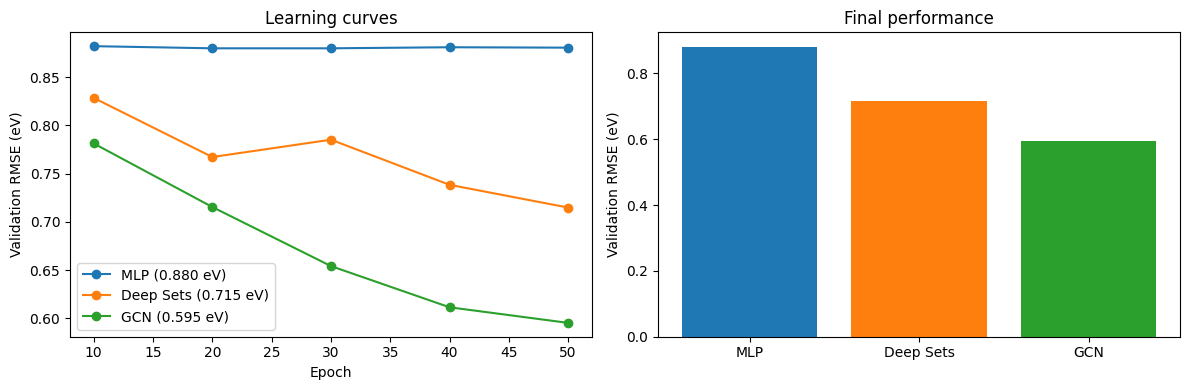


MLP:       0.880 eV
Deep Sets: 0.715 eV
GCN:       0.595 eV


In [ ]:
epochs = np.arange(10, 51, 10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Validation RMSE curves
for name, vals, color in [("MLP", mlp_val, "C0"), ("Deep Sets", ds_val, "C1"), ("GCN", gcn_val, "C2")]:
    ax1.plot(epochs, vals, "o-", label=f"{name} ({vals[-1]:.3f} eV)", color=color)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Validation RMSE (eV)")
ax1.legend()
ax1.set_title("Learning curves")

# Final bar chart
names = ["MLP", "Deep Sets", "GCN"]
final_vals = [mlp_val[-1], ds_val[-1], gcn_val[-1]]
colors = ["C0", "C1", "C2"]
ax2.bar(names, final_vals, color=colors)
ax2.set_ylabel("Validation RMSE (eV)")
ax2.set_title("Final performance")

plt.tight_layout()
plt.show()

print(f"\nMLP:       {mlp_val[-1]:.3f} eV")
print(f"Deep Sets: {ds_val[-1]:.3f} eV")
print(f"GCN:       {gcn_val[-1]:.3f} eV")